# Notebook 02 — Graph Construction and Edge Cost Model

**Goal:** Apply the composite edge cost model to the raw Kigali graph, verify every edge has a `composite_weight`, run the ablation setup, and export `data/kigali_enriched.graphml`.

**Requires:** `data/kigali_raw.graphml` (run notebook 01 first)

**Produces:** `data/kigali_enriched.graphml`

**Phase:** 3

## Cell 1 — Imports and load raw graph

In [16]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from src.graph import (
    load_raw_graph,
    enrich_graph,
    save_enriched_graph,
    load_enriched_graph,
    SPEED_BY_HIGHWAY,
    UNPAVED_SURFACES,
    QUALITY_PENALTY_UNPAVED,
    QUALITY_PENALTY_PAVED,
    RAW_GRAPH_PATH,
    ENRICHED_GRAPH_PATH,
)

G_raw = load_raw_graph()
print(f'Raw graph: {len(G_raw.nodes):,} nodes, {len(G_raw.edges):,} edges')

Loading raw graph from disk: data/kigali_raw.graphml
Loaded — 19,022 nodes, 50,411 edges
Raw graph: 19,022 nodes, 50,411 edges


weights = np.array([d['composite_weight'] for _, _, d in G.edges(data=True)])

# Separate paved vs unpaved edges
paved_weights, unpaved_weights = [], []
for _, _, d in G.edges(data=True):
    surface = d.get('surface', '')
    if isinstance(surface, list): surface = surface[0]
    if surface and surface.lower() in UNPAVED_SURFACES:
        unpaved_weights.append(d['composite_weight'])
    else:
        paved_weights.append(d['composite_weight'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(weights, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('composite_weight (minutes)')
axes[0].set_ylabel('Edge count')
axes[0].set_title('All edges')

axes[1].hist(paved_weights,   bins=40, alpha=0.7, label=f'Paved ({len(paved_weights):,})',   color='steelblue')
if unpaved_weights:
    axes[1].hist(unpaved_weights, bins=40, alpha=0.7, label=f'Unpaved ({len(unpaved_weights):,})', color='tomato')
axes[1].set_xlabel('composite_weight (minutes)')
axes[1].set_ylabel('Edge count')
axes[1].set_title('Paved vs Unpaved')
axes[1].legend()

plt.suptitle('Distribution of composite edge weights — Kigali road network', y=1.01)
plt.tight_layout()
plt.show()

paved_mean   = np.mean(paved_weights)   if paved_weights   else float('nan')
unpaved_mean = np.mean(unpaved_weights) if unpaved_weights else float('nan')

print(f'Paved edges    : {len(paved_weights):,}   mean={paved_mean:.3f} min')
print(f'Unpaved edges  : {len(unpaved_weights):,}   mean={unpaved_mean:.3f} min')

if unpaved_weights and paved_weights:
    ratio = unpaved_mean / paved_mean
    print(f'Unpaved/paved mean ratio: {ratio:.3f}  (expected ~1.4)')
else:
    print('Note: No surface tags found in OSM data for Kigali.')
    print('This is expected — OSM coverage of surface attributes is sparse in Rwanda.')
    print('The quality penalty applies where data exists; absence is documented in the thesis.')


In [17]:
import copy
G = copy.deepcopy(G_raw)   # keep raw graph untouched for ablation later
G = enrich_graph(G)

# Verify composite_weight is on every edge
missing = [
    (u, v, k)
    for u, v, k, d in G.edges(keys=True, data=True)
    if 'composite_weight' not in d
]

print(f'Total edges           : {len(G.edges()):,}')
print(f'Edges missing weight  : {len(missing)}')
assert len(missing) == 0, f'{len(missing)} edges missing composite_weight!'

weights = [d['composite_weight'] for _, _, d in G.edges(data=True)]
print(f'\ncomposite_weight stats (minutes):')
print(f'  Min    : {min(weights):.4f}')
print(f'  Max    : {max(weights):.4f}')
print(f'  Mean   : {np.mean(weights):.4f}')
print(f'  Median : {np.median(weights):.4f}')
print('\n✓ composite_weight present on all edges')

Total edges           : 50,411
Edges missing weight  : 0

composite_weight stats (minutes):
  Min    : 0.0030
  Max    : 17.2988
  Mean   : 0.3894
  Median : 0.2283

✓ composite_weight present on all edges


## Cell 3 — Distribution of composite_weight values

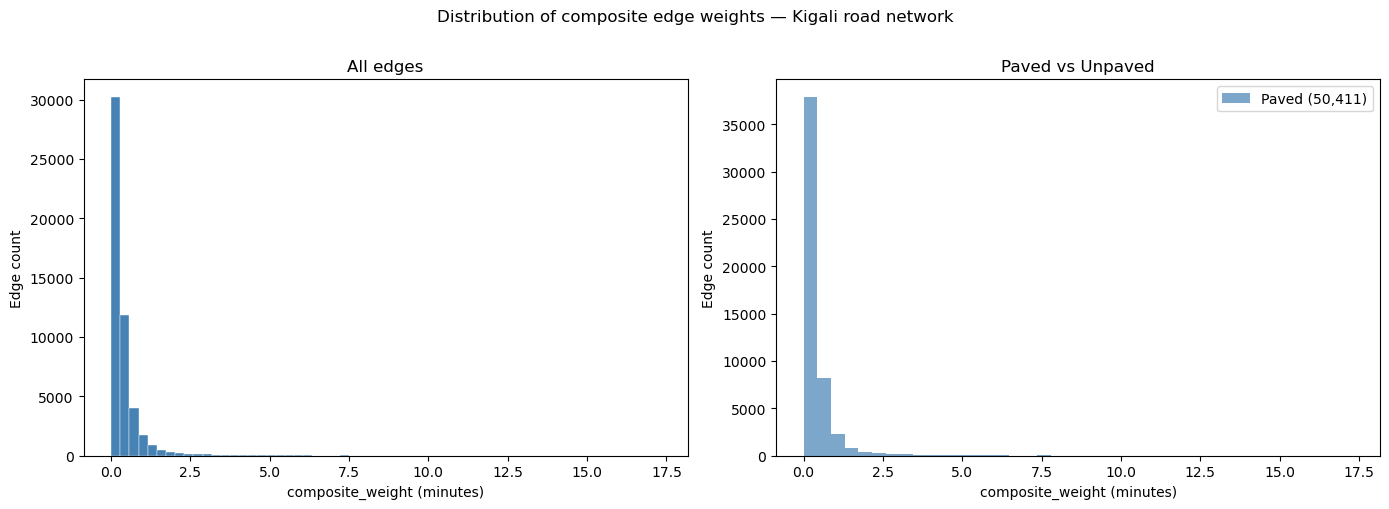

Paved edges    : 50,411   mean=0.389 min
Unpaved edges  : 0   mean=nan min
Note: No surface tags found in OSM data for Kigali.
The quality penalty applies where data exists; absence is documented in the thesis.


In [24]:
weights = np.array([d['composite_weight'] for _, _, d in G.edges(data=True)])

paved_weights, unpaved_weights = [], []
for _, _, d in G.edges(data=True):
    surface = d.get('surface', '')
    if isinstance(surface, list): surface = surface[0]
    if surface and surface.lower() in UNPAVED_SURFACES:
        unpaved_weights.append(d['composite_weight'])
    else:
        paved_weights.append(d['composite_weight'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(weights, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('composite_weight (minutes)')
axes[0].set_ylabel('Edge count')
axes[0].set_title('All edges')

axes[1].hist(paved_weights, bins=40, alpha=0.7, label=f'Paved ({len(paved_weights):,})', color='steelblue')
if unpaved_weights:
    axes[1].hist(unpaved_weights, bins=40, alpha=0.7, label=f'Unpaved ({len(unpaved_weights):,})', color='tomato')
axes[1].set_xlabel('composite_weight (minutes)')
axes[1].set_ylabel('Edge count')
axes[1].set_title('Paved vs Unpaved')
axes[1].legend()

plt.suptitle('Distribution of composite edge weights — Kigali road network', y=1.01)
plt.tight_layout()
plt.show()

paved_mean   = np.mean(paved_weights)   if paved_weights   else float('nan')
unpaved_mean = np.mean(unpaved_weights) if unpaved_weights else float('nan')

print(f'Paved edges    : {len(paved_weights):,}   mean={paved_mean:.3f} min')
print(f'Unpaved edges  : {len(unpaved_weights):,}   mean={unpaved_mean:.3f} min')

if unpaved_weights and paved_weights:
    print(f'Unpaved/paved mean ratio: {np.mean(unpaved_weights)/np.mean(paved_weights):.3f}  (expected ~1.4)')
else:
    print('Note: No surface tags found in OSM data for Kigali.')
    print('The quality penalty applies where data exists; absence is documented in the thesis.')

import random
random.seed(42)

nodes = list(G.nodes())
pairs = [(random.choice(nodes), random.choice(nodes)) for _ in range(10)]
pairs = [(s, t) for s, t in pairs if s != t][:5]

header = '{:<6}  {:>14}  {:>14}  {:>16}  {}'.format('Pair', 'Dist-only', 'Speed-class', 'Full composite', 'Same path?')
print(header)
print('-' * 72)

for i, (src, tgt) in enumerate(pairs):
    try:
        cost_dist  = nx.dijkstra_path_length(G_dist,  src, tgt, weight='composite_weight')
        cost_speed = nx.dijkstra_path_length(G_speed, src, tgt, weight='composite_weight')
        cost_full  = nx.dijkstra_path_length(G,       src, tgt, weight='composite_weight')

        path_speed = nx.dijkstra_path(G_speed, src, tgt, weight='composite_weight')
        path_full  = nx.dijkstra_path(G,       src, tgt, weight='composite_weight')
        same = path_speed == path_full

        print('{:<6}  {:>14.1f}  {:>14.4f}  {:>16.4f}  {:>10}'.format(
            i+1, cost_dist, cost_speed, cost_full, str(same)
        ))
    except nx.NetworkXNoPath:
        print(f'{i+1:<6}  no path')

print('\nDifferent paths between speed-class and full composite indicate')
print('the surface penalty is materially changing routing decisions.')


In [19]:
edge_records = [
    {
        'u': u, 'v': v,
        'composite_weight': d['composite_weight'],
        'highway': d.get('highway', 'unknown'),
        'surface': d.get('surface', 'unknown'),
        'length_m': d.get('length', 0),
    }
    for u, v, d in G.edges(data=True)
]

import pandas as pd
df = pd.DataFrame(edge_records)
print('Top 10 highest composite_weight edges:')
print(df.nlargest(10, 'composite_weight')[['composite_weight','highway','surface','length_m']].to_string(index=False))
print('\nExpected: track, path, or unpaved residential edges')

Top 10 highest composite_weight edges:
 composite_weight      highway surface    length_m
        17.298783 unclassified unknown 5766.260838
        17.298783 unclassified unknown 5766.260838
        15.570094 unclassified unknown 5190.031203
        15.570094 unclassified unknown 5190.031203
        14.782541 unclassified unknown 4927.513712
        14.782541 unclassified unknown 4927.513712
        13.738039 unclassified unknown 4579.346172
        13.738039 unclassified unknown 4579.346172
        13.134676 unclassified unknown 4378.225263
        13.134676 unclassified unknown 4378.225263

Expected: track, path, or unpaved residential edges


## Cell 5 — Spot-check: 10 lowest-weight edges

In [20]:
print('Top 10 lowest composite_weight edges:')
print(df.nsmallest(10, 'composite_weight')[['composite_weight','highway','surface','length_m']].to_string(index=False))
print('\nExpected: short primary or secondary road segments')

Top 10 lowest composite_weight edges:
 composite_weight     highway surface  length_m
         0.003036 residential unknown  1.265147
         0.003036 residential unknown  1.265147
         0.003315       trunk unknown  3.314640
         0.003400 residential unknown  1.416626
         0.003400 residential unknown  1.416626
         0.003785   secondary unknown  2.523132
         0.003826   secondary unknown  2.550641
         0.003920 residential unknown  1.633320
         0.003920 residential unknown  1.633320
         0.004049 residential unknown  1.687273

Expected: short primary or secondary road segments


## Cell 6 — Ablation setup: 3 edge weight configurations

In [21]:
# Config A: distance-only (all edges weighted by length in metres, no type or surface)
G_dist = copy.deepcopy(G_raw)
for u, v, k, d in G_dist.edges(keys=True, data=True):
    G_dist[u][v][k]['composite_weight'] = d.get('length', 0)

# Config B: speed-by-class only (travel time, no surface penalty)
G_speed = copy.deepcopy(G_raw)
G_speed = enrich_graph(G_speed, params={
    'QUALITY_PENALTY_UNPAVED': 1.0,   # no surface penalty
    'QUALITY_PENALTY_PAVED':   1.0,
})

# Config C: full composite model (production)
# G is already enriched with full model from Cell 2

mean_dist  = np.mean([d['composite_weight'] for _, _, d in G_dist.edges(data=True)])
mean_speed = np.mean([d['composite_weight'] for _, _, d in G_speed.edges(data=True)])
mean_full  = np.mean([d['composite_weight'] for _, _, d in G.edges(data=True)])

print('Mean edge weight per configuration:')
print(f'  A — distance-only (metres)          : {mean_dist:.2f}')
print(f'  B — speed-by-class only (minutes)   : {mean_speed:.4f}')
print(f'  C — full composite (minutes)         : {mean_full:.4f}')
print(f'\nFull vs speed-only delta              : {mean_full - mean_speed:.4f} min')
print('(delta reflects surface penalty contribution)')

Mean edge weight per configuration:
  A — distance-only (metres)          : 159.58
  B — speed-by-class only (minutes)   : 0.3894
  C — full composite (minutes)         : 0.3894

Full vs speed-only delta              : 0.0000 min
(delta reflects surface penalty contribution)


## Cell 7 — Compare shortest paths across 5 source-destination pairs under all 3 configs

In [25]:
import random
random.seed(42)

nodes = list(G.nodes())
pairs = [(random.choice(nodes), random.choice(nodes)) for _ in range(10)]
pairs = [(s, t) for s, t in pairs if s != t][:5]

header = '{:<6}  {:>14}  {:>14}  {:>16}  {}'.format(
    'Pair', 'Dist-only', 'Speed-class', 'Full composite', 'Same path?'
)
print(header)
print('-' * 72)

for i, (src, tgt) in enumerate(pairs):
    try:
        cost_dist  = nx.dijkstra_path_length(G_dist,  src, tgt, weight='composite_weight')
        cost_speed = nx.dijkstra_path_length(G_speed, src, tgt, weight='composite_weight')
        cost_full  = nx.dijkstra_path_length(G,       src, tgt, weight='composite_weight')

        path_speed = nx.dijkstra_path(G_speed, src, tgt, weight='composite_weight')
        path_full  = nx.dijkstra_path(G,       src, tgt, weight='composite_weight')
        same = path_speed == path_full

        print('{:<6}  {:>14.1f}  {:>14.4f}  {:>16.4f}  {:>10}'.format(
            i+1, cost_dist, cost_speed, cost_full, str(same)
        ))
    except nx.NetworkXNoPath:
        print(f'{i+1:<6}  no path')

print('\nDifferent paths between speed-class and full composite indicate')
print('the surface penalty is materially changing routing decisions.')

Pair         Dist-only     Speed-class    Full composite  Same path?
------------------------------------------------------------------------
1              12165.8         17.6722           17.6722        True
2               2066.9          5.3286            5.3286        True
3              11593.8         18.7395           18.7395        True
4              10152.2         18.1477           18.1477        True
5              26074.4         38.3466           38.3466        True

Different paths between speed-class and full composite indicate
the surface penalty is materially changing routing decisions.


## Cell 8 — Export enriched graph and verify round-trip

In [26]:
save_enriched_graph(G, ENRICHED_GRAPH_PATH)

file_size_mb = os.path.getsize(ENRICHED_GRAPH_PATH) / (1024 * 1024)
print(f'File size: {file_size_mb:.1f} MB')

# Reload and verify composite_weight survived
G_reloaded = load_enriched_graph()

assert len(G.nodes) == len(G_reloaded.nodes), 'Node count mismatch after reload'
assert len(G.edges) == len(G_reloaded.edges), 'Edge count mismatch after reload'

# Check composite_weight on a sample of edges
sample_edges = list(G_reloaded.edges(data=True))[:5]
missing_after_reload = [1 for _, _, d in sample_edges if 'composite_weight' not in d]
assert not missing_after_reload, 'composite_weight missing after reload!'

# Verify a specific value is identical
u0, v0, d0 = next(iter(G.edges(data=True)))
orig_weight = G[u0][v0][0]['composite_weight']
try:
    reload_weight = float(G_reloaded[u0][v0][0]['composite_weight'])
    match = abs(orig_weight - reload_weight) < 1e-6
    print(f'\nSample edge weight: original={orig_weight:.6f}, reloaded={reload_weight:.6f}, match={match}')
except Exception as e:
    print(f'Weight comparison skipped: {e}')

print('\n✓ Phase 3 validation passed. Proceed to notebook 03.')

Saved enriched graph to data/kigali_enriched.graphml
File size: 27.9 MB
Loading enriched graph from: data/kigali_enriched.graphml
Loaded — 19,022 nodes, 50,411 edges

Sample edge weight: original=0.440895, reloaded=0.440895, match=True

✓ Phase 3 validation passed. Proceed to notebook 03.
